In [5]:
import numpy as np

house_a = np.array([3, 1500, 5])
house_b = np.array([2, 800, 12])

In [6]:
distance = np.linalg.norm(house_a - house_b)
print(f"Difference Score: {distance:.2f}")

Difference Score: 700.04


In [7]:
house_b = np.array([5000, 800, 12])

In [8]:
distance = np.linalg.norm(house_a - house_b)
print(f"Difference Score: {distance:.2f}")

Difference Score: 5045.80


In [9]:
import pandas as pd

# Meeting 17,000 houses at once
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
print(df.shape)

(17000, 9)


In [10]:
print(df.describe)

<bound method NDFrame.describe of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population

<Figure size 1000x700 with 0 Axes>

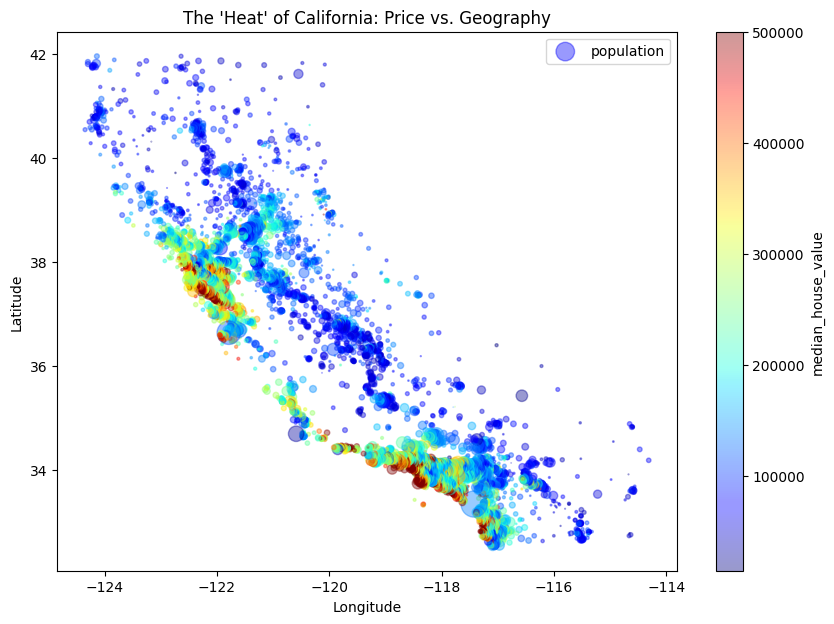

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# 2. Create the Heatmap
# We use longitude/latitude for position and price for the color (c)
plt.figure(figsize=(10,7))
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=df["population"]/100, label="population", figsize=(10,7),
        c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)

plt.title("The 'Heat' of California: Price vs. Geography")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Prepare the data
X = df[['median_income']] # Features
y = df['median_house_value'] # Target

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [13]:
# Predict for a neighborhood where the median income is 5.0 ($50,000)
income_input = [[5.0]]
predicted_price = model.predict(income_input)

print(f"For an income of $50k, the AI predicts a house value of: ${predicted_price[0]:,.2f}")

For an income of $50k, the AI predicts a house value of: $253,587.96


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# 2. Define Multiple Features (X) and Target (y)
features = ['median_income', 'total_rooms', 'housing_median_age']
X = df[features]
y = df['median_house_value']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the upgraded model
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# 5. Get the 'Grade' (R-Squared Score)
score = multi_model.score(X_test, y_test)
print(f"Upgraded Model R-squared Score: {score:.4f}")

Upgraded Model R-squared Score: 0.5423


In [15]:
# Predict for a neighborhood where the median income is 5.0 ($50,000)
income_input = [[5.0]]
predicted_price = model.predict(income_input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Create binary target
median_price = df['median_house_value'].median()
df['above_median'] = (df['median_house_value'] > median_price).astype(int)

In [18]:
# Features and target
X = df[['median_income', 'total_rooms', 'housing_median_age']]
y = df['above_median']

In [19]:
# Same train-test split as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [20]:
# Predict
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.77
